# Notebook 04 — XGBoost (Machine Learning Model)

**Goal:** Train a gradient-boosted tree model using engineered lag and calendar features.

This turns the forecasting problem into a supervised regression problem.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from data_loader import get_monthly_total
from evaluation import evaluate
from models import make_ml_features, ML_FEATURES

plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
results = pd.read_csv('../results/model_results.csv').to_dict('records')

## Step 1: Build features (lags, rolling means, calendar)

In [3]:
fd = make_ml_features(y).dropna()
print('Features:', ML_FEATURES)
print('Rows after feature engineering:', len(fd))
fd.head()

Features: ['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'rm3', 'rm6', 'month', 'quarter']
Rows after feature engineering: 87


,y,lag1,lag2,lag3,lag6,lag12,rm3,rm6,month,quarter
Date,,,,,,,,,,
2019-01-31,244239.0,253169.0,195582.0,153123.0,217829.0,238924.0,200624.666667,194858.166667,1,1
2019-02-28,252033.0,244239.0,253169.0,195582.0,200359.0,235618.0,230996.666667,199259.833333,2,1
2019-03-31,244328.0,252033.0,244239.0,253169.0,149087.0,233382.0,249813.666667,207872.166667,3,1
2019-04-30,166975.0,244328.0,252033.0,244239.0,153123.0,180429.0,246866.666667,223745.666667,4,2
2019-05-31,37802.0,166975.0,244328.0,252033.0,195582.0,129466.0,221112.000000,226054.333333,5,2


## Step 2: Train/test split

In [4]:
tr = fd[fd.index < '2025-01-01']
te = fd[fd.index >= '2025-01-01']
X_train, y_train = tr[ML_FEATURES], tr['y']
X_test, y_test = te[ML_FEATURES], te['y']
print('Train:', len(X_train), 'Test:', len(X_test))

Train: 72 Test: 15


## Step 3: Train XGBoost

In [5]:
model = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
xgb_fc = pd.Series(model.predict(X_test), index=y_test.index)
results.append(evaluate(y_test, xgb_fc, 'XGBoost'))

XGBoost                         MAE=   31,507  RMSE=   38,651  MAPE= 16.63%


## Step 4: Feature importance

Shows which features the model relied on most.

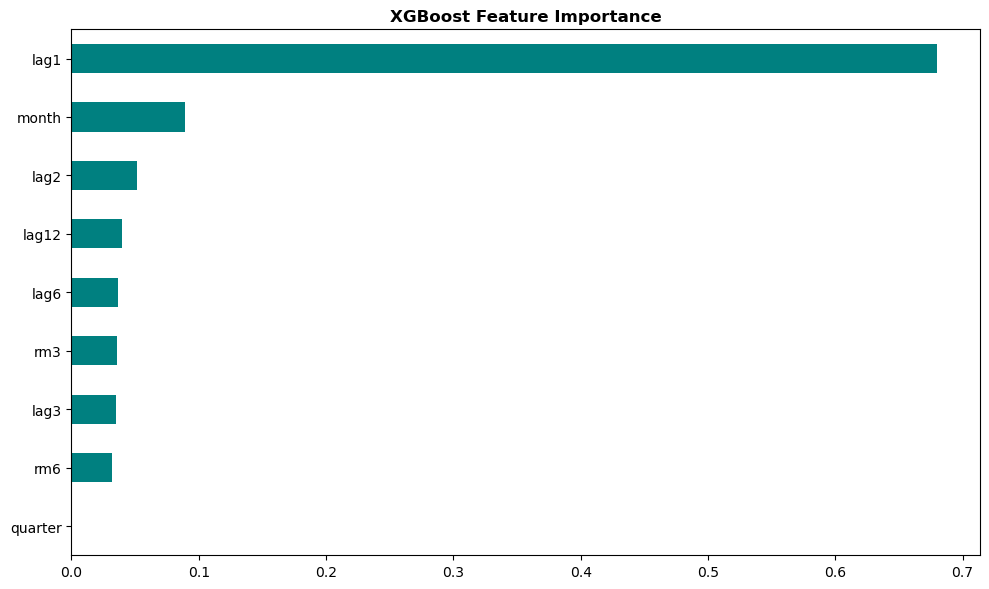

In [6]:
plt.figure(figsize=(10,6))
imp = pd.Series(model.feature_importances_, index=ML_FEATURES).sort_values()
imp.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importance', fontweight='bold')
plt.tight_layout(); plt.savefig('../results/04_xgb_importance.png', dpi=150); plt.show()

## Step 5: Plot forecast

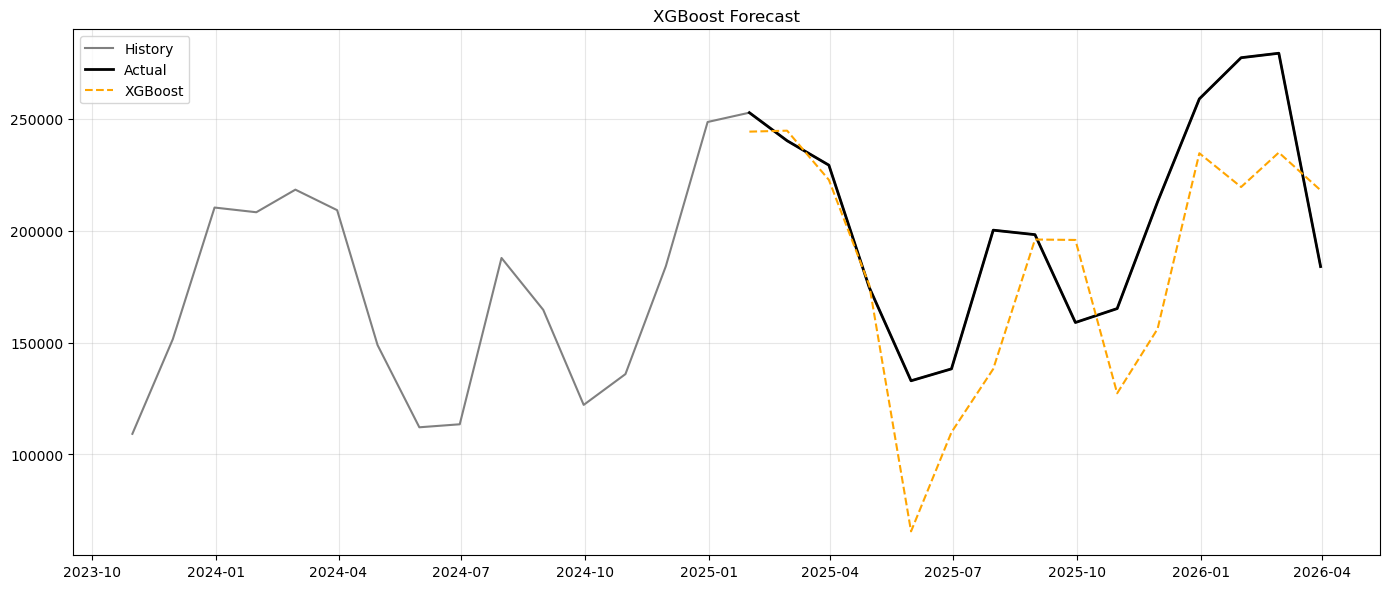

In [7]:
plt.figure()
plt.plot(y.index[-30:], y.values[-30:], label='History', color='gray')
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, xgb_fc.values, '--', label='XGBoost', color='orange')
plt.title('XGBoost Forecast'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../results/04_xgboost.png', dpi=150); plt.show()

In [8]:
pd.DataFrame(results).to_csv('../results/model_results.csv', index=False)
print('Saved. Move to 05_hybrid_sarima_xgboost.ipynb')

Saved. Move to 05_hybrid_sarima_xgboost.ipynb
